# CS383 — Assignment 1
## Joining and Cleaning Restaurant Inspection Data

*Due: see LMS*

### Scenario
You've been given access to a small relational database of NYC restaurant inspection records, split across three tables:

- `restaurants` — one row per establishment
- `inspections` — one row per inspection visit
- `violations` — one row per violation cited during an inspection

Your task is to write SQL queries that join across these tables, then move into Pandas to clean and summarize what you find.

**This is the first time you're seeing this specific database.** That's intentional — use what you learned about `SELECT`, `WHERE`, `GROUP BY`, joins, and schema-checking (`PRAGMA table_info`, `.dtypes`, `.head()`) to explore it yourself before answering the required questions below. Nothing here has been walked through in class.

---

### Academic integrity and using AI

This assignment is meant to show **your own** understanding of joins and data cleaning — it's the checkpoint that tells you (and your instructor) whether you're ready for Assignment 2 and the capstone, so it needs to reflect what you can actually do without help.

**Allowed** — using an AI tool (Claude, ChatGPT, GitHub Copilot, etc.) as a *tutor*: asking it to explain a concept, explain an error message, explain what a piece of syntax does, or point you toward the right Pandas/SQL method to look up.

**Not allowed** — pasting the assignment questions (or this dataset) into an AI tool and submitting what it gives back; having AI write your queries or code for you; having AI write your reasoning or summary write-ups for you.

A good test: if you can't explain — out loud, without looking anything up — exactly what every line of your submitted notebook does and why, it isn't ready to submit. You may be asked to walk through your code in person; work you can't explain will not receive credit, whether or not AI was involved.

---

### Getting started

Run the cell below once. It builds the three tables above from live NYC Open Data if there's a network connection available, or realistic sample data if not. **Do not skip or modify this cell** — everything after it assumes these three tables exist in `restaurant_inspections.db`.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd

try:
    raw_path = os.path.expanduser("~/shared/restaurant_inspections_snapshot.csv")
    raw = pd.read_csv(raw_path).head(15000)
    if "score" in raw.columns:
        raw["score"] = pd.to_numeric(raw["score"], errors="coerce")

    restaurants = raw[["camis", "dba", "boro", "cuisine_description"]].drop_duplicates(
        subset="camis"
    ).reset_index(drop=True)

    inspections = raw[["camis", "inspection_date", "action", "score", "grade"]].drop_duplicates(
        subset=["camis", "inspection_date"]
    ).reset_index(drop=True)
    inspections.insert(0, "inspection_id", range(1, len(inspections) + 1))

    with_ids = raw.merge(
        inspections[["camis", "inspection_date", "inspection_id"]], on=["camis", "inspection_date"]
    )
    violations = with_ids.loc[
        with_ids["violation_code"].notna(),
        ["inspection_id", "violation_code", "violation_description", "critical_flag"],
    ].reset_index(drop=True)

    live = True

except Exception:
    # Offline fallback, in case there is no internet connection in the room.
    rng = np.random.default_rng(383)

    boroughs_list = ["MANHATTAN", "BROOKLYN", "QUEENS", "BRONX", "STATEN ISLAND"]
    cuisines_clean = ["American", "Chinese", "Italian", "Mexican", "Pizza",
                       "Japanese", "Caribbean", "Bakery", "Coffee/Tea", "Chicken"]

    n_restaurants = 150
    camis_ids = np.arange(50_000_001, 50_000_001 + n_restaurants)
    restaurants = pd.DataFrame({
        "camis": camis_ids,
        "dba": [f"Restaurant {i + 1}" for i in range(n_restaurants)],
        "boro": rng.choice(boroughs_list, size=n_restaurants, p=[0.22, 0.32, 0.26, 0.16, 0.04]),
        "cuisine_description": rng.choice(cuisines_clean, size=n_restaurants),
    })

    # Deliberately messy cuisine text on a chunk of rows (inconsistent case/whitespace).
    messy_idx = rng.choice(restaurants.index, size=20, replace=False)
    def _messify(s):
        pick = rng.integers(0, 3)
        if pick == 0:
            return s.upper()
        elif pick == 1:
            return f"  {s.lower()}  "
        return s.lower()
    restaurants.loc[messy_idx, "cuisine_description"] = restaurants.loc[
        messy_idx, "cuisine_description"
    ].apply(_messify)

    # A handful of exact duplicate restaurant rows.
    restaurants = pd.concat(
        [restaurants, restaurants.sample(5, random_state=1)], ignore_index=True
    )

    n_inspections = 400
    inspections = pd.DataFrame({
        "inspection_id": np.arange(1, n_inspections + 1),
        "camis": rng.choice(camis_ids, size=n_inspections),
        "inspection_date": pd.date_range("2025-01-01", periods=n_inspections, freq="18h").astype(str),
        "action": "Violations were cited in the following area(s).",
        "score": rng.integers(0, 60, size=n_inspections),
        "grade": rng.choice(["A", "B", "C", None], size=n_inspections, p=[0.55, 0.25, 0.10, 0.10]),
    })
    # A few duplicate inspection rows too.
    inspections = pd.concat(
        [inspections, inspections.sample(4, random_state=2)], ignore_index=True
    )

    violation_pool = [
        ("04L", "Evidence of mice or live mice present", "Critical"),
        ("06C", "Food not protected from potential source of contamination", "Critical"),
        ("08A", "Facility not vermin proof", "Not Critical"),
        ("10F", "Non-food contact surface improperly constructed", "Not Critical"),
        ("02B", "Hot food item not held at or above 140 F", "Critical"),
        ("04N", "Filth flies or food/refuse/sewage-associated flies present", "Critical"),
        ("06D", "Food contact surface not properly washed", "Critical"),
        ("05D", "Hand washing facility not accessible", "Critical"),
    ]
    n_violations = 700
    picks = rng.integers(0, len(violation_pool), size=n_violations)
    violations = pd.DataFrame({
        "inspection_id": rng.choice(inspections["inspection_id"].unique(), size=n_violations),
        "violation_code": [violation_pool[i][0] for i in picks],
        "violation_description": [violation_pool[i][1] for i in picks],
        "critical_flag": [violation_pool[i][2] for i in picks],
    })

    live = False

print(f"{'Shared snapshot' if live else 'Offline fallback'} data loaded.")
print(f"restaurants: {len(restaurants):,} rows | inspections: {len(inspections):,} rows | violations: {len(violations):,} rows")

conn = sqlite3.connect("restaurant_inspections.db")
restaurants.to_sql("restaurants", conn, if_exists="replace", index=False)
inspections.to_sql("inspections", conn, if_exists="replace", index=False)
violations.to_sql("violations", conn, if_exists="replace", index=False)

print("Tables ready in restaurant_inspections.db: restaurants, inspections, violations")

Shared snapshot data loaded.
restaurants: 4,279 rows | inspections: 4,529 rows | violations: 14,867 rows
Tables ready in restaurant_inspections.db: restaurants, inspections, violations


---

### Explore before you answer

Before jumping into the required questions, take a few minutes to look around:

- What columns does each table have, and what do they look like? (`PRAGMA table_info(...)`, `.dtypes`, `.head()`)
- How do the three tables relate to each other — which columns would you join on?
- Do you notice anything odd or messy in the data as you look at it?

Use the scratch cell below (and add more cells if you want) to explore. This part isn't graded directly, but it'll make the required questions much easier.

In [ ]:
# Scratch space -- explore restaurants, inspections, and violations here.


---

## Required Deliverable 1 — Restaurants Per Cuisine, Cleaned

The `cuisine_description` column has inconsistent capitalization and stray whitespace in places, and the `restaurants` table has a few exact duplicate rows.

Clean both issues in Pandas, then produce a count of restaurants per (cleaned) cuisine type, sorted from most to fewest.

In [2]:
# Your code here.
#cleaning up Capitalization and WhiteSpace 
restaurants['cuisine_description'] = restaurants['cuisine_description'].str.strip().str.title()
#.strip() strips whitespace 
#removing duplicate row 
restaurants = restaurants.drop_duplicates()
#count the resturant per cuisine type 
cuisine_counts = restaurants['cuisine_description'].value_counts()
cuisine_counts

cuisine_description
American          643
Chinese           399
Coffee/Tea        379
Pizza             238
Latin American    196
                 ... 
English             1
Ethiopian           1
Afghan              1
Lebanese            1
Cajun               1
Name: count, Length: 82, dtype: int64

---

## Required Deliverable 2 — Worst Inspection Scores, With Restaurant Names (JOIN required)

Using a SQL `JOIN` across `restaurants` and `inspections`, find the 10 individual inspections with the **highest** score (a higher score means more violations) among inspections that also received a letter grade.

Your result should include: restaurant name, borough, cuisine, inspection date, score, and grade.

In [7]:
# Your code here.
SQL = """
SELECT 
    restaurants.dba, 
    restaurants.boro, 
    restaurants.cuisine_description, 
    inspections.inspection_date, 
    inspections.score, 
    inspections.grade
FROM restaurants
JOIN inspections ON restaurants.camis = inspections.camis
WHERE inspections.grade IS NOT NULL
ORDER BY inspections.score DESC
LIMIT 10;
"""

# Just pass your variable name into pd.read_sql_query
pd.read_sql_query(SQL, conn)

,dba,boro,cuisine_description,inspection_date,score,grade
0,STEINBERG'S KOSHER BAKERY,Brooklyn,Jewish/Kosher,2025-12-23T00:00:00.000,143.0,N
1,CARIBBEAN CRAVE RESTAURANT,Queens,Caribbean,2026-01-28T00:00:00.000,131.0,N
2,PANAJACHEL SOLOLA,Brooklyn,Other,2026-08-26T00:00:00.000,130.0,N
3,"PICK AND CHEESE, LAYAWAY BAR AND BODEGA",Manhattan,Other,2026-05-26T00:00:00.000,100.0,N
4,INDIA PASSAGE,Bronx,Bangladeshi,2025-11-24T00:00:00.000,96.0,N
5,TOMPKINS SQUARE BAGELS,Manhattan,Other,2026-05-26T00:00:00.000,92.0,N
6,CHICK CHICK,Manhattan,Chicken,2026-05-26T00:00:00.000,89.0,N
7,YUZU MORDERN ASIAN KITCHEN.,Brooklyn,Jewish/Kosher,2025-10-29T00:00:00.000,86.0,C
8,ASIAN HALAL KITCHEN,Queens,Southeast Asian,2026-09-02T00:00:00.000,85.0,N
9,NORIHANA,Manhattan,Japanese,2026-05-26T00:00:00.000,84.0,N


---

## Required Deliverable 3 — Most Common Critical Violations, By Cuisine (JOIN required, all 3 tables)

Pick one cuisine type. Using SQL `JOIN`s across all three tables, find the 5 most common `"Critical"` violation descriptions among restaurants of that cuisine.

Then reproduce the same result using Pandas `.merge()` instead of SQL, and confirm the two approaches agree.

In [8]:
# SQL version -- your code here.
chosen_cuisine = 'Italian'  # Feel free to change this to any cuisine you like!

SQL = f"""
SELECT 
    violations.violation_description, 
    COUNT(*) AS count
FROM restaurants
JOIN inspections ON restaurants.camis = inspections.camis
JOIN violations ON inspections.inspection_id = violations.inspection_id
WHERE restaurants.cuisine_description = '{chosen_cuisine}'
  AND violations.critical_flag = 'Critical'
GROUP BY violations.violation_description
ORDER BY count DESC
LIMIT 5;
"""

sql_result = pd.read_sql_query(SQL, conn)
sql_result


,violation_description,count
0,Cold TCS food item held above 41 °F; smoked or...,43
1,"Food contact surface not properly washed, rins...",38
2,"Food, supplies, or equipment not protected fro...",36
3,Hot TCS food item not held at or above 140 °F.,22
4,Evidence of mice or live mice in establishment...,20


In [9]:
# Pandas version -- your code here.
# 1. Merge all three tables
merged = restaurants.merge(inspections, on='camis').merge(violations, on='inspection_id')

# 2. Filter for your chosen cuisine and critical violations
filtered = merged[
    (merged['cuisine_description'] == chosen_cuisine) & 
    (merged['critical_flag'] == 'Critical')
]

# 3. Get top 5 critical violations
pandas_result = filtered['violation_description'].value_counts().head(5).reset_index()
pandas_result.columns = ['violation_description', 'count']
pandas_result

,violation_description,count
0,Cold TCS food item held above 41 °F; smoked or...,43
1,"Food contact surface not properly washed, rins...",38
2,"Food, supplies, or equipment not protected fro...",36
3,Hot TCS food item not held at or above 140 °F.,22
4,Evidence of mice or live mice in establishment...,20


In [10]:
# Confirm the SQL and Pandas results agree -- your code here.
# Check if both DataFrames have matching values using .equal() function 
pandas_result.equals(sql_result)

True

---

## Required Deliverable 4 — Handle the Missing Grades

Not every inspection has a letter grade — some are still missing (`None` / `NaN`).

Decide how to handle this for the purpose of computing an **average score by grade**: drop the missing rows? Label them `"Ungraded"` and keep them separate? Something else? Write one or two sentences explaining your reasoning *before* your code, then implement it.

**Your reasoning:**
I decided to label missing values as 'Ungraded' because dropping those rows would remove valid inspection scores and other useful restaurant details. Categorizing them as 'Ungraded' lets us calculate averages for letter grades while keeping all inspection data intact for analysis.

In [12]:
# Your code here.
# Copy dataframe and fill missing grade values with 'Ungraded'
#fillna () is usned to replace missing blank values with things like ungraded instead of none or NULL or NaN
inspections_cleaned = inspections.copy()
inspections_cleaned['grade'] = inspections_cleaned['grade'].fillna('Ungraded')

# Calculate average score by grade
avg_scores = inspections_cleaned.groupby('grade')['score'].mean().reset_index()
avg_scores

,grade,score
0,A,9.805568
1,B,21.731544
2,C,36.520548
3,N,30.194175
4,P,0.733333
5,Ungraded,31.015067
6,Z,22.547170


---

## Required Deliverable 5 — Summary for a Non-Technical Reader

Pick one finding from your analysis above that an actual restaurant-goer (not a data scientist) would care about.

Produce one clean summary table or chart, and write a two-to-three sentence explanation in plain language — no jargon, no code terms. Imagine you're telling a friend, not writing a lab report.

,boro,A,B,C,N,P,Z,Total,% Grade A,% Non-A
0,Bronx,217,17,3,16,1,23,277,78.3,21.7
1,Brooklyn,570,32,18,81,6,51,758,75.2,24.8
2,Manhattan,847,46,24,137,4,74,1132,74.8,25.2
3,Queens,544,48,28,55,4,55,734,74.1,25.9
4,Staten Island,85,6,0,21,0,9,121,70.2,29.8


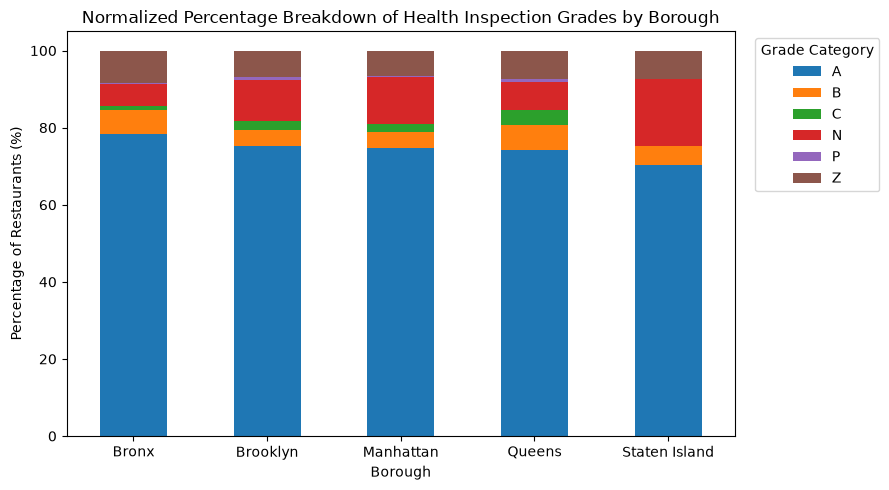

In [16]:
# Your code here.
import matplotlib.pyplot as plt

# 1. Merge restaurants and inspections on 'camis'
restaurant_grades = restaurants.merge(inspections, on='camis')

# 2. Filter out rows where grade is missing (None/NaN)
graded_restaurants = restaurant_grades.dropna(subset=['grade'])

# 3. Create cross-tabulation table for all grade counts by borough
boro_grade_counts = pd.crosstab(graded_restaurants['boro'], graded_restaurants['grade']).reset_index()
boro_grade_counts.columns.name = None

# 4. Calculate total graded restaurants per borough
boro_grade_counts['Total'] = boro_grade_counts[['A', 'B', 'C', 'N', 'P', 'Z']].sum(axis=1)

# 5. Calculate percentage of restaurants receiving Grade A (top grade)
boro_grade_counts['% Grade A'] = (boro_grade_counts['A'] / boro_grade_counts['Total'] * 100).round(1)

# 6. Calculate percentage of restaurants with non-A grades (B, C, N, P, Z combined)
boro_grade_counts['% Non-A'] = ((boro_grade_counts['Total'] - boro_grade_counts['A']) / boro_grade_counts['Total'] * 100).round(1)

# Display the updated summary table with counts, totals, and normalized percentages
display(boro_grade_counts)

# 7. Plot normalized stacked bar chart (percentages) for clean borough comparison
boro_pcts = boro_grade_counts.set_index('boro')[['A', 'B', 'C', 'N', 'P', 'Z']].apply(lambda x: x / x.sum() * 100, axis=1)

boro_pcts.plot(
    kind='bar', 
    stacked=True, 
    figsize=(9, 5)
)
plt.title('Normalized Percentage Breakdown of Health Inspection Grades by Borough')
plt.xlabel('Borough')
plt.ylabel('Percentage of Restaurants (%)')
plt.xticks(rotation=0)
plt.legend(title='Grade Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Your summary (plain language):**
Looking across all five NYC boroughs, the Bronx and Brooklyn have the highest percentage of top-grade 'A' restaurants, with nearly 78% receiving top marks. In contrast, Staten Island has the lowest proportion of 'A' grades, with roughly 30% of its restaurants receiving lower letter grades or pending status codes. Checking the official grade posted in the window helps diners spot whether a restaurant has clean health marks regardless of which borough they are dining in.



---

## Grading Rubric

| Criterion | Points |
|---|---|
| Deliverable 1 — cleaning is correct and counts are right | 15 |
| Deliverable 2 — JOIN is correct and produces the right 10 rows | 20 |
| Deliverable 3 — 3-table JOIN correct; SQL and Pandas results genuinely match | 25 |
| Deliverable 4 — reasoning is stated and implementation matches it | 15 |
| Deliverable 5 — finding is genuinely non-technical, table/chart is clear | 15 |
| Notebook runs top to bottom without errors | 10 |
| **Total** | **100** |

---

## Submission

### One-time GitHub setup (reused for every assignment this semester)

1. On github.com, create one new **public** repository named `cs383-assignments`. You'll keep reusing this same repo all semester — one folder per assignment, not a new repo each time.
2. Inside it, create a folder for this assignment: `assignment1/`.
3. Put your completed notebook in that folder, keeping its original filename: `assignment1_restaurant_inspections.ipynb`.

If you've never pushed to this repo before, from inside your project folder run:

```bash
git init
git remote add origin <your-repo-URL>
git branch -M main
```

(Prefer a GUI? GitHub Desktop or VS Code's built-in Git panel do the same thing without the command line.)

### Every time you submit

```bash
git add -A
git commit -m "Assignment 1: restaurant inspections"
git push
```

Submit the **direct link to your notebook file on GitHub** (not just the repo homepage — the URL should end in `assignment1/assignment1_restaurant_inspections.ipynb`) on BrightSpace under **Assignment 1**.

Make sure your notebook runs top to bottom without errors before you submit — a notebook that only works because cells were run out of order will not be graded as passing.